# 05 -- Effect relationships (Phase 3, first look)
Studies the relationship between the genotype-alone vote (`genetic_value`,
`03`'s GBLUP) and the environment-alone vote (`environment_value`, `04`'s
env_mlp_l2, lambda=1.0), then a first-cut fusion formula, at the
**Hybrid x Env cell-mean** level (mean yield per hybrid-environment
combination, not raw plot-level -- matches classical G x E specification and
avoids replicate-count pseudoreplication).

**Deliberately no CV in this notebook**, per current request -- this is a
first look at the shapes of these relationships, not a final fusion model.
`genetic_value` and `environment_value` below are each model's **final,
fully-fit, in-sample** prediction (`03`'s GBLUP at alpha=0.1, `04`'s
env_mlp_l2 at lambda=1.0 -- both hardcoded here from those notebooks' actual
final runs, not re-selected). That means every in-sample number in this
notebook is optimistic to some degree, most for the two relationship MLPs
(steps 4-5) which could in principle memorize their training rows. **Before
any of this feeds a real fusion model, the plan discussed is to rebuild
`genetic_value`/`environment_value` as leave-one-year-out out-of-fold
predictions**, reusing `03`'s and `04`'s existing fold structure -- flagged
again at the bottom, not silently forgotten.

One bonus check IS out-of-sample: Section 6 evaluates the fitted fusion
formulas against the true 2024 holdout, since `03`'s and `04`'s final models
already generalize to 2024 by construction (2024 was never in either
model's training years) -- cheap to check, and the project convention is to
always report train and test side by side.

**What "the third model" (environment_value -> pheno) actually shows:**
worth being precise going in. `environment_value` is constant across every
hybrid tested in a given `Env` -- it has zero within-environment variation.
So a model `environment_value -> pheno` (Hybrid x Env cell mean) can never
explain within-env variation (that's genotype/G x E territory); what it
learns is a **recalibration curve of env_mlp_l2's own output against true
average phenotype** -- under/over-prediction at the extremes, scale or
offset drift, curvature introduced by env_mlp_l2's L2 shrinkage. Still
useful (splicing it into the fusion formula in place of a plain linear term
is the whole point), just not "new" environmental information beyond what
`environment_value` already encodes.

**Model capacity note:** every relationship model here is scalar-in/scalar-
out (1 input feature). `03`'s and `04`'s MLPs needed 24-256 hidden units
because they had 39-2,425 real input features; these need far less --
8 hidden units is already generous for a 1D relationship, not a compromise.
Kept narrow deliberately, since interpretability of the *shape* is the point
of a diagnostic layer, not squeezing out marginal accuracy.

## Setup

In [1]:
import os
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/g2f_effect_decomposition')
else:
    BASE_PATH = Path(os.environ.get('G2F_BASE_PATH', '.')).resolve()

sys.path.insert(0, str(BASE_PATH))

DATA_RAW = BASE_PATH / 'data' / 'raw'
RESULTS_DIR = BASE_PATH / 'results' / 'effect_relationships'
MODELS_DIR = RESULTS_DIR / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB: {IN_COLAB}")
print(f"BASE_PATH: {BASE_PATH}")

Mounted at /content/drive
IN_COLAB: True
BASE_PATH: /content/drive/MyDrive/g2f_effect_decomposition


In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

from scripts.genotype_models import vanraden_allele_freq, vanraden_denominator, vanraden_kernel
from scripts.environment_models import (
    match_weather_columns, engineer_env_weather_features,
    build_soil_features, env_feature_mean_std, EnvMLP, env_l2_penalty,
)
from scripts.relationship_models import scalar_feature_mean_std, ScalarMLP, scalar_l2_penalty
from scripts.training import reliability_weights, make_loader, fit_mlp_adam, GBLUPModel
from scripts.evaluation import evaluate_predictions

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Carried over from 03's and 04's own CV-selected/chosen final hyperparameters
# -- NOT re-selected here, since this notebook skips CV. If either upstream
# notebook's selection changes, update these two lines.
GBLUP_ALPHA = 0.1          # 03's most_common_gblup_alpha() result
ENV_MLP_LAMBDA = 1.0       # 04's hand-picked final lambda (see chat log)
ENV_MLP_HIDDEN = 24        # unchanged from 04

# Relationship-model hyperparameters -- quick-look defaults, not swept.
REL_HIDDEN = 8
REL_L2_LAMBDA = 1e-4
BATCH_SIZE = 256
NUM_EPOCHS = 150
PATIENCE = 15
ADAM_LR = 1e-4

## Load data
Same raw files `03` and `04` each load, combined -- trait/genotype for
GBLUP, weather/soil/meta for env_mlp, plus the 2024 test-side files for the
bonus out-of-sample check in Section 6.

In [4]:
TRAIN_DIR = DATA_RAW / 'Training_data'
TEST_DIR = DATA_RAW / 'Testing_data'

trait_df = pd.read_csv(TRAIN_DIR / '1_Training_Trait_Data_2014_2023.csv')
geno_num = pd.read_csv(TRAIN_DIR / '5_Genotype_Data_All_2014_2025_Hybrids_numerical.txt',
                        sep='\t', skiprows=1)
weather_season_df = pd.read_csv(TRAIN_DIR / '4_Training_Weather_Data_2014_2023_seasons_only.csv')
soil_df = pd.read_csv(TRAIN_DIR / '3_Training_Soil_Data_2015_2023.csv')
meta_df = pd.read_csv(TRAIN_DIR / '2_Training_Meta_Data_2014_2023.csv')
test_observed_df = pd.read_csv(TEST_DIR / '7_Testing_Observed_Values.csv')
test_weather_season_df = pd.read_csv(TEST_DIR / '4_Testing_Weather_Data_2024_seasons_only.csv')
test_soil_df = pd.read_csv(TEST_DIR / '3_Testing_Soil_Data_2024.csv')
test_meta_df = pd.read_csv(TEST_DIR / '2_Testing_Meta_Data_2024.csv')

geno_id_col = geno_num.columns[0]
geno_num = geno_num.set_index(geno_id_col)
geno_num.index = geno_num.index.astype(str)

trait_clean = trait_df.dropna(subset=['Yield_Mg_ha']).copy()
trait_clean['Hybrid'] = trait_clean['Hybrid'].astype(str)
genotyped_hybrids = set(geno_num.index)
trait_genotyped = trait_clean[trait_clean['Hybrid'].isin(genotyped_hybrids)].copy()

print(f"trait_genotyped: {len(trait_genotyped)} rows, "
      f"{trait_genotyped['Hybrid'].nunique()} genotyped hybrids, "
      f"{trait_genotyped['Env'].nunique()} environments")

trait_genotyped: 163026 rows, 4938 genotyped hybrids, 272 environments


In [5]:
weather_cols = [c for c in weather_season_df.columns if c not in ('Env', 'Date')]
matched = match_weather_columns(weather_cols)
env_weather_features = engineer_env_weather_features(weather_season_df, matched)

soil_env_col = next((c for c in soil_df.columns if c.lower() == 'env'), 'Env')
soil_features_raw = build_soil_features(soil_df, env_col=soil_env_col)

meta_cols = list(meta_df.columns)
lat_col = next((c for c in meta_cols if 'latitude' in c.lower() or c.lower() == 'lat'), None)
lon_col = next((c for c in meta_cols if 'longitude' in c.lower() or 'long' in c.lower() or c.lower() == 'lon'), None)
meta_env_col = next((c for c in meta_cols if c.lower() == 'env'), 'Env')
location_features = meta_df.set_index(meta_env_col)[[lat_col, lon_col]]

# Same fallback safety net as 04 -- see that notebook's markdown for why this
# is necessary (sparse soil columns / Env-key join mismatches can leave a
# statistic undefined even outside a CV-fold context).
_global_reference = pd.concat(
    [env_weather_features, soil_features_raw.add_prefix('soil_').reindex(env_weather_features.index),
     location_features.reindex(env_weather_features.index)], axis=1
)
GLOBAL_FEATURE_MEDIAN = _global_reference.median()


def impute_remaining_nan(df: pd.DataFrame, context: str) -> pd.DataFrame:
    if not df.isna().any().any():
        return df
    bad_cols = df.columns[df.isna().any()].tolist()
    print(f"  [{context}] fold-safe statistic undefined for {bad_cols} -- "
          f"fallback-imputing from the all-years global median instead")
    return df.fillna(GLOBAL_FEATURE_MEDIAN)


# Environments with a target but no matched weather record -- same generic
# detection as 04.
all_target_envs = trait_genotyped['Env'].unique()
ENVS_WITHOUT_WEATHER = sorted(set(all_target_envs) - set(env_weather_features.index))
trait_genotyped_modelable = trait_genotyped[~trait_genotyped['Env'].isin(ENVS_WITHOUT_WEATHER)].copy()

print(f"Environments without weather (excluded): {ENVS_WITHOUT_WEATHER}")
print(f"trait_genotyped_modelable: {len(trait_genotyped_modelable)} rows, "
      f"{trait_genotyped_modelable['Hybrid'].nunique()} hybrids, "
      f"{trait_genotyped_modelable['Env'].nunique()} environments")

Environments without weather (excluded): ['TXH2_2015', 'TXH2_2016', 'TXH2_2017']
trait_genotyped_modelable: 161803 rows, 4934 hybrids, 269 environments


## 1. Final GBLUP fit (no CV) -- `genetic_value`
Ported verbatim from `03`'s final-fit cell: median-impute markers on the
final training hybrid set, VanRaden kinship kernel, `GBLUPModel(alpha=0.1)`.
Predicts on the exact same hybrids it was fit on (in-sample, per this
notebook's scope -- see intro).

In [6]:
def build_hybrid_targets(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby('Hybrid')['Yield_Mg_ha']
    n_envs = df.groupby('Hybrid')['Env'].nunique()
    return pd.DataFrame({'hybrid_mean_yield': grouped.mean(), 'n_envs_tested': n_envs})


final_hybrid_targets = build_hybrid_targets(trait_genotyped)
final_train_hybrids = final_hybrid_targets.index.tolist()

marker_median_final = geno_num.loc[final_train_hybrids].median()
geno_imputed_final = geno_num.fillna(marker_median_final)
X_train_final_raw = geno_imputed_final.loc[final_train_hybrids].to_numpy(dtype=np.float64)

allele_freq_final = vanraden_allele_freq(X_train_final_raw)
denom_final = vanraden_denominator(allele_freq_final)
G_train_final = vanraden_kernel(X_train_final_raw, X_train_final_raw, allele_freq_final, denom_final)

weights_train_gblup = reliability_weights(final_hybrid_targets.loc[final_train_hybrids, 'n_envs_tested'].to_numpy())
y_train_gblup = final_hybrid_targets.loc[final_train_hybrids, 'hybrid_mean_yield'].to_numpy(dtype=np.float32)

gblup_model = GBLUPModel(alpha=GBLUP_ALPHA)
gblup_model.fit(G_train_final, y_train_gblup, sample_weight=weights_train_gblup)

genetic_value_by_hybrid = pd.Series(
    gblup_model.predict(G_train_final), index=final_train_hybrids, name='genetic_value')

print(f"genetic_value: {len(genetic_value_by_hybrid)} hybrids, "
      f"train pearson_r={evaluate_predictions(y_train_gblup, genetic_value_by_hybrid.values)['pearson_r']:.3f} "
      f"(in-sample -- expected high, this is a fit-quality check not a generalization check)")

genetic_value: 4938 hybrids, train pearson_r=0.848 (in-sample -- expected high, this is a fit-quality check not a generalization check)


## 2. Final env_mlp_l2 fit (no CV, lambda=1.0) -- `environment_value`
Ported from `04`'s final-fit cell, with the hand-picked lambda from the chat
discussion rather than `04`'s CV-auto-selected 0.1 (the two were within
noise of each other in CV, see prior discussion).

In [9]:
def build_env_targets(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby('Env')['Yield_Mg_ha']
    n_hybrids = df.groupby('Env')['Hybrid'].nunique()
    return pd.DataFrame({'env_mean_yield': grouped.mean(), 'n_hybrids_tested': n_hybrids})


final_env_targets = build_env_targets(trait_genotyped_modelable)
final_train_envs = final_env_targets.index.tolist()

soil_median_final = soil_features_raw.loc[soil_features_raw.index.isin(final_train_envs)].median()
soil_imputed_final = soil_features_raw.reindex(env_weather_features.index).fillna(soil_median_final)
has_soil_flag_final = soil_features_raw.reindex(env_weather_features.index).notna().all(axis=1).astype(int)
soil_imputed_final.columns = [f'soil_{c}' for c in soil_imputed_final.columns]
train_combined_final = pd.concat(
    [env_weather_features, soil_imputed_final, has_soil_flag_final.rename('has_soil_data'),
     location_features.reindex(env_weather_features.index)], axis=1,
)
train_combined_final = impute_remaining_nan(train_combined_final, 'env final train')

FEATURE_COLS = train_combined_final.columns.tolist()
X_train_env_raw = train_combined_final.loc[final_train_envs, FEATURE_COLS].to_numpy(dtype=np.float64)
mean_env_final, std_env_final = env_feature_mean_std(X_train_env_raw)
X_train_env_std = (X_train_env_raw - mean_env_final) / std_env_final

weights_train_env = reliability_weights(final_env_targets.loc[final_train_envs, 'n_hybrids_tested'].to_numpy())
y_train_env = final_env_targets.loc[final_train_envs, 'env_mean_yield'].to_numpy(dtype=np.float32)

env_model = EnvMLP(X_train_env_std.shape[1], hidden_dim=ENV_MLP_HIDDEN)
train_loader = make_loader(X_train_env_std, y_train_env, weights_train_env, BATCH_SIZE, shuffle=True)
penalty_fn = lambda m: env_l2_penalty(m, ENV_MLP_LAMBDA)
env_model, _ = fit_mlp_adam(env_model, train_loader, train_loader, penalty_fn, ADAM_LR,
                             NUM_EPOCHS, PATIENCE, DEVICE, checkpoint_path=MODELS_DIR / 'env_mlp_l2_relationship.pt')

env_model.eval()
with torch.no_grad():
    env_preds = env_model(torch.as_tensor(X_train_env_std, dtype=torch.float32).to(DEVICE)).cpu().numpy()

environment_value_by_env = pd.Series(env_preds, index=final_train_envs, name='environment_value')

print(f"environment_value: {len(environment_value_by_env)} environments, "
      f"train pearson_r={evaluate_predictions(y_train_env, env_preds)['pearson_r']:.3f} (in-sample)")

  [env final train] fold-safe statistic undefined for ['Weather_Station_Latitude (in decimal numbers NOT DMS)', 'Weather_Station_Longitude (in decimal numbers NOT DMS)'] -- fallback-imputing from the all-years global median instead
  Epoch 0: train_loss=106.3774, val_loss=99.1144
  Epoch 10: train_loss=111.5036, val_loss=103.6171
  Epoch 20: train_loss=93.0164, val_loss=107.1624
  Early stopping at epoch 24
environment_value: 269 environments, train pearson_r=-0.130 (in-sample)


## 3. Hybrid x Env cell-mean join table
`pheno` = mean yield per (Hybrid, Env) combination actually observed in
`trait_genotyped_modelable`. `n_plot_records` (replicate count backing that
cell) becomes the reliability weight for everything downstream in this
notebook -- reusing `reliability_weights` unchanged, same convention as
`03`/`04`.

In [10]:
cell_means = (
    trait_genotyped_modelable.groupby(['Hybrid', 'Env'])['Yield_Mg_ha']
    .agg(pheno='mean', n_plot_records='size')
    .reset_index()
)
cell_means['genetic_value'] = cell_means['Hybrid'].map(genetic_value_by_hybrid)
cell_means['environment_value'] = cell_means['Env'].map(environment_value_by_env)

missing = cell_means[['genetic_value', 'environment_value']].isna().any(axis=1).sum()
print(f"cell_means: {len(cell_means)} Hybrid x Env cells "
      f"({cell_means['Hybrid'].nunique()} hybrids x {cell_means['Env'].nunique()} envs)")
print(f"Rows with a missing genetic_value or environment_value (should be 0): {missing}")

cell_means = cell_means.dropna(subset=['genetic_value', 'environment_value']).reset_index(drop=True)
cell_weights = reliability_weights(cell_means['n_plot_records'].to_numpy())

cell_means: 106037 Hybrid x Env cells (4934 hybrids x 269 envs)
Rows with a missing genetic_value or environment_value (should be 0): 0


## 4. Confound check: does `genetic_value` predict `environment_value`?
The motivating question from the project's confound-auditing background: if
certain hybrids are systematically over-tested in certain kinds of
environments (real phenomenon in this field -- regional adaptation,
commercial-hybrid targeting), genotype's and environment's votes could
correlate for a design reason rather than a biological one. Plain
correlation first, then the two small cross-prediction MLPs, on every
observed (Hybrid, Env) pair (not deduplicated -- the repetition reflects the
actual assignment pattern, which is exactly what's being audited).

In [11]:
pearson_ge = evaluate_predictions(cell_means['environment_value'], cell_means['genetic_value'])['pearson_r']
print(f"Pearson r(genetic_value, environment_value) across {len(cell_means)} observed cells: {pearson_ge:.3f}")

Pearson r(genetic_value, environment_value) across 106037 observed cells: 0.054


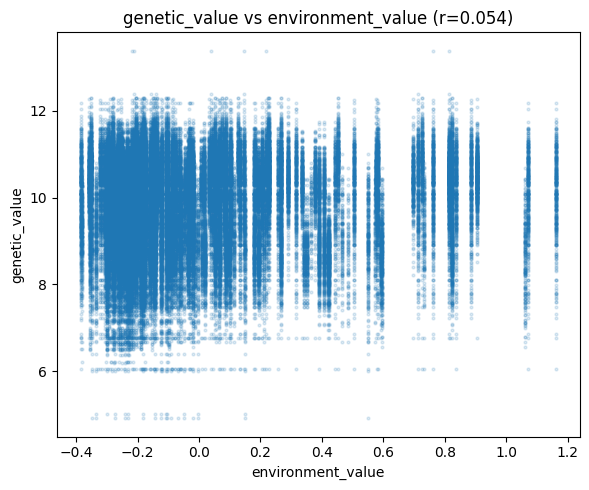

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(cell_means['environment_value'], cell_means['genetic_value'], s=4, alpha=0.15)
ax.set_xlabel('environment_value')
ax.set_ylabel('genetic_value')
ax.set_title(f'genetic_value vs environment_value (r={pearson_ge:.3f})')
plt.tight_layout()
plt.show()

In [13]:
def fit_scalar_mlp(x: np.ndarray, y: np.ndarray, weights: np.ndarray, label: str):
    x_mean, x_std = scalar_feature_mean_std(x)
    x_std_arr = ((x - x_mean) / x_std).reshape(-1, 1).astype(np.float32)
    y_arr = y.astype(np.float32)

    model = ScalarMLP(n_in=1, hidden_dim=REL_HIDDEN)
    loader = make_loader(x_std_arr, y_arr, weights, BATCH_SIZE, shuffle=True)
    penalty_fn = lambda m: scalar_l2_penalty(m, REL_L2_LAMBDA)
    model, _ = fit_mlp_adam(model, loader, loader, penalty_fn, ADAM_LR, NUM_EPOCHS, PATIENCE, DEVICE, verbose=False)

    model.eval()
    with torch.no_grad():
        pred = model(torch.as_tensor(x_std_arr, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    r = evaluate_predictions(y_arr, pred)['pearson_r']
    print(f"{label}: MLP train pearson_r={r:.3f} (plain-correlation baseline: {pearson_ge:.3f})")
    return model, x_mean, x_std


geno_to_env_model, gv_mean, gv_std = fit_scalar_mlp(
    cell_means['genetic_value'].to_numpy(), cell_means['environment_value'].to_numpy(),
    cell_weights, 'genetic_value -> environment_value')

env_to_geno_model, ev_mean_a, ev_std_a = fit_scalar_mlp(
    cell_means['environment_value'].to_numpy(), cell_means['genetic_value'].to_numpy(),
    cell_weights, 'environment_value -> genetic_value')

genetic_value -> environment_value: MLP train pearson_r=0.066 (plain-correlation baseline: 0.054)
environment_value -> genetic_value: MLP train pearson_r=0.080 (plain-correlation baseline: 0.054)


## 5. The functional form of `environment_value -> pheno`
This is `h()` -- see the intro for what it can and can't show (a
recalibration curve, not new environmental signal). Fit the same way as the
cross-prediction pair above, just with `pheno` as the target instead of
`genetic_value`.

In [14]:
h_model, ev_mean_b, ev_std_b = fit_scalar_mlp(
    cell_means['environment_value'].to_numpy(), cell_means['pheno'].to_numpy(),
    cell_weights, 'environment_value -> pheno (h)')


def h_predict(environment_value: np.ndarray) -> np.ndarray:
    x_std_arr = ((environment_value - ev_mean_b) / ev_std_b).reshape(-1, 1).astype(np.float32)
    h_model.eval()
    with torch.no_grad():
        return h_model(torch.as_tensor(x_std_arr, dtype=torch.float32).to(DEVICE)).cpu().numpy()


cell_means['h_environment_value'] = h_predict(cell_means['environment_value'].to_numpy())

environment_value -> pheno (h): MLP train pearson_r=0.148 (plain-correlation baseline: 0.054)


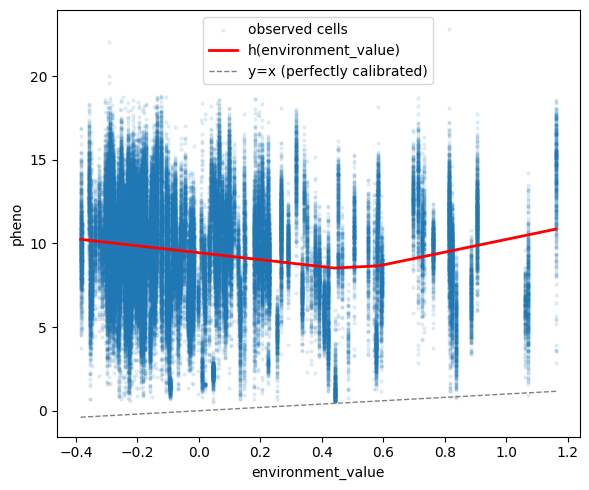

In [15]:
order = np.argsort(cell_means['environment_value'].to_numpy())
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(cell_means['environment_value'], cell_means['pheno'], s=4, alpha=0.1, label='observed cells')
ax.plot(cell_means['environment_value'].to_numpy()[order], cell_means['h_environment_value'].to_numpy()[order],
        color='red', linewidth=2, label='h(environment_value)')
ax.plot(cell_means['environment_value'].to_numpy()[order], cell_means['environment_value'].to_numpy()[order],
        color='gray', linestyle='--', linewidth=1, label='y=x (perfectly calibrated)')
ax.set_xlabel('environment_value')
ax.set_ylabel('pheno')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Fusion: linear baseline, then splicing in `h()`
Baseline: `pheno ~ a*genetic_value + b*environment_value + bias`, weighted
least squares (reliability weight = cell replicate count). Improved: same
form, `environment_value` replaced by `h(environment_value)` -- `b` is left
free rather than fixed at 1, since `h()` itself may not be perfectly
calibrated in scale even after correcting its shape.

In [16]:
X_baseline = cell_means[['genetic_value', 'environment_value']].to_numpy()
X_improved = cell_means[['genetic_value', 'h_environment_value']].to_numpy()
y_pheno = cell_means['pheno'].to_numpy()

baseline_reg = LinearRegression().fit(X_baseline, y_pheno, sample_weight=cell_weights)
improved_reg = LinearRegression().fit(X_improved, y_pheno, sample_weight=cell_weights)

baseline_pred = baseline_reg.predict(X_baseline)
improved_pred = improved_reg.predict(X_improved)

fusion_comparison = pd.DataFrame([
    {
        'formula': 'baseline (linear)', 'a_genetic': baseline_reg.coef_[0], 'b_environment': baseline_reg.coef_[1],
        'bias': baseline_reg.intercept_, **evaluate_predictions(y_pheno, baseline_pred),
    },
    {
        'formula': 'improved (h-spliced)', 'a_genetic': improved_reg.coef_[0], 'b_environment': improved_reg.coef_[1],
        'bias': improved_reg.intercept_, **evaluate_predictions(y_pheno, improved_pred),
    },
])
fusion_comparison

,formula,a_genetic,b_environment,bias,pearson_r,rmse
0,baseline (linear),1.060212,-0.949242,-0.735996,0.370320,2.772905
1,improved (h-spliced),1.044875,0.849602,-8.746741,0.380822,2.760286


### Bonus: evaluating both fusion formulas against the true 2024 holdout
The one genuinely out-of-sample check available without rebuilding CV: 2024
was never in `genetic_value`'s or `environment_value`'s training years, so
predicting 2024 Hybrid x Env cells is a real generalization test for the
*fitted coefficients* (`a`, `b`, `bias`, and `h()`'s learned shape) even
though the relationship models themselves were fit in-sample above.

In [17]:
test_env_weather_cols = [c for c in test_weather_season_df.columns if c not in ('Env', 'Date')]
test_matched = match_weather_columns(test_env_weather_cols)
test_env_weather_features = engineer_env_weather_features(test_weather_season_df, test_matched)

test_soil_env_col = next((c for c in test_soil_df.columns if c.lower() == 'env'), 'Env')
test_soil_features_raw = build_soil_features(test_soil_df, env_col=test_soil_env_col)

test_meta_env_col = next((c for c in test_meta_df.columns if c.lower() == 'env'), 'Env')
test_location_features = test_meta_df.set_index(test_meta_env_col)[[lat_col, lon_col]]

test_soil_imputed = test_soil_features_raw.reindex(test_env_weather_features.index).fillna(soil_median_final)
test_has_soil_flag = test_soil_features_raw.reindex(test_env_weather_features.index).notna().all(axis=1).astype(int)
test_soil_imputed.columns = [f'soil_{c}' for c in test_soil_imputed.columns]
test_combined = pd.concat(
    [test_env_weather_features, test_soil_imputed, test_has_soil_flag.rename('has_soil_data'),
     test_location_features.reindex(test_env_weather_features.index)], axis=1,
)
test_combined = test_combined.reindex(columns=FEATURE_COLS)
test_combined = test_combined.fillna(pd.concat([soil_median_final.add_prefix('soil_')]))
test_combined = impute_remaining_nan(test_combined, 'env final test')

X_test_env_raw = test_combined.loc[test_env_weather_features.index, FEATURE_COLS].to_numpy(dtype=np.float64)
X_test_env_std = (X_test_env_raw - mean_env_final) / std_env_final

env_model.eval()
with torch.no_grad():
    test_env_preds = env_model(torch.as_tensor(X_test_env_std, dtype=torch.float32).to(DEVICE)).cpu().numpy()
environment_value_by_env_test = pd.Series(test_env_preds, index=test_env_weather_features.index, name='environment_value')

test_observed_df['Hybrid'] = test_observed_df['Hybrid'].astype(str)
test_hybrids_genotyped = [h for h in test_observed_df['Hybrid'].unique() if h in genotyped_hybrids]
X_test_geno_raw = geno_imputed_final.reindex(index=test_hybrids_genotyped).to_numpy(dtype=np.float64)
# hybrids present in test but absent from geno_imputed_final (no genotype OR
# never appeared in 2014-2023 training years) can't get a marker-median
# fallback from the training imputation -- reindex would leave NaN rows;
# drop them rather than silently feeding NaN into the kernel.
valid_test_geno_mask = ~np.isnan(X_test_geno_raw).any(axis=1)
test_hybrids_genotyped = [h for h, ok in zip(test_hybrids_genotyped, valid_test_geno_mask) if ok]
X_test_geno_raw = X_test_geno_raw[valid_test_geno_mask]

G_test_geno = vanraden_kernel(X_test_geno_raw, X_train_final_raw, allele_freq_final, denom_final)
genetic_value_by_hybrid_test = pd.Series(
    gblup_model.predict(G_test_geno), index=test_hybrids_genotyped, name='genetic_value')

test_cell_means = (
    test_observed_df.groupby(['Hybrid', 'Env'])['Yield_Mg_ha']
    .agg(pheno='mean', n_plot_records='size')
    .reset_index()
)
test_cell_means['genetic_value'] = test_cell_means['Hybrid'].map(genetic_value_by_hybrid_test)
test_cell_means['environment_value'] = test_cell_means['Env'].map(environment_value_by_env_test)
test_cell_means = test_cell_means.dropna(subset=['genetic_value', 'environment_value']).reset_index(drop=True)
test_cell_means['h_environment_value'] = h_predict(test_cell_means['environment_value'].to_numpy())

print(f"Test cell_means: {len(test_cell_means)} Hybrid x Env cells "
      f"({test_cell_means['Hybrid'].nunique()} hybrids x {test_cell_means['Env'].nunique()} envs)")

  [env final test] fold-safe statistic undefined for ['Weather_Station_Latitude (in decimal numbers NOT DMS)', 'Weather_Station_Longitude (in decimal numbers NOT DMS)'] -- fallback-imputing from the all-years global median instead
Test cell_means: 9486 Hybrid x Env cells (1063 hybrids x 22 envs)


In [18]:
X_test_baseline = test_cell_means[['genetic_value', 'environment_value']].to_numpy()
X_test_improved = test_cell_means[['genetic_value', 'h_environment_value']].to_numpy()
y_test_pheno = test_cell_means['pheno'].to_numpy()

test_baseline_pred = baseline_reg.predict(X_test_baseline)
test_improved_pred = improved_reg.predict(X_test_improved)

final_comparison = pd.DataFrame([
    {'formula': 'genetic_value alone', **evaluate_predictions(y_test_pheno, test_cell_means['genetic_value'])},
    {'formula': 'environment_value alone', **evaluate_predictions(y_test_pheno, test_cell_means['environment_value'])},
    {'formula': 'baseline fusion (linear)', **evaluate_predictions(y_test_pheno, test_baseline_pred)},
    {'formula': 'improved fusion (h-spliced)', **evaluate_predictions(y_test_pheno, test_improved_pred)},
])
final_comparison

,formula,pearson_r,rmse
0,genetic_value alone,0.116366,3.031744
1,environment_value alone,-0.348164,11.124406
2,baseline fusion (linear),0.257472,2.897965
3,improved fusion (h-spliced),0.058785,3.152407


## Save results

In [ ]:
cell_means.to_csv(RESULTS_DIR / 'train_cell_means_with_votes.csv', index=False)
test_cell_means.to_csv(RESULTS_DIR / 'test_cell_means_with_votes.csv', index=False)
fusion_comparison.to_csv(RESULTS_DIR / 'fusion_train_comparison.csv', index=False)
final_comparison.to_csv(RESULTS_DIR / 'fusion_test_comparison.csv', index=False)

print(f"Saved to {RESULTS_DIR}")
print("  train_cell_means_with_votes.csv -- Hybrid x Env cells with genetic_value/environment_value/pheno")
print("  test_cell_means_with_votes.csv  -- same, for the true 2024 holdout")
print("  fusion_train_comparison.csv     -- baseline vs improved fusion, in-sample")
print("  fusion_test_comparison.csv      -- genotype-alone vs environment-alone vs both fusion formulas, true 2024 holdout")

## Summary
Fill in after running:
- `Pearson r(genetic_value, environment_value)`: is there a detectable
  design confound, or are the two votes close to independent as they would
  be under balanced random testing?
- Do the cross-prediction MLPs meaningfully beat the plain correlation, or
  is the relationship already ~linear (in which case the extra MLP capacity
  isn't buying anything and a simple correlation report is enough going
  forward)?
- Does `h(environment_value)` show real curvature vs the y=x reference line
  in the Section 5 plot, or does env_mlp_l2's output already look
  well-calibrated against true phenotype?
- Does the improved (h-spliced) fusion actually beat the linear baseline on
  the **test** comparison, not just train -- a curve fit in-sample can look
  better on train and not transfer.
- How do both fusion formulas compare to genotype-alone and
  environment-alone individually on the test set -- is fusion earning its
  complexity, the central question this whole framework exists to answer?
- **Before treating any of this as final**: rebuild `genetic_value` and
  `environment_value` as leave-one-year-out out-of-fold predictions (reusing
  `03`'s and `04`'s existing fold code) and re-run Sections 3-6 -- every
  in-sample number here is a first look, not a validated result.